<a href="https://colab.research.google.com/github/fargonemaciel/infnet-machine-learning-codes/blob/main/feature_engineering_fargone_maciel_flor_DR2_TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dados para Machine Learning: Feature Engineering [26E1_2]

### Teste de Performance - TP3 [Obrigatório]

In [ ]:
#Libraries Install

!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.5 MB/s eta 0:00:00


In [ ]:
# Libraries Import

import kagglehub
import os
import pandas as pd
import warnings
import numpy as np
import patsy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize
from time import time
from mglearn.tools import visualize_coefficients

warnings.filterwarnings("ignore")

### 1 Análise de Sentimentos com TF-IDF e Regressão Logística

**Questão 1**

Baixe e carregue o dataset alexa.tsv, com as amostras de avaliações feitas por clientes da Amazon sobre produtos adquiridos da linha Alexa, tais como Echo, Dot, Alexa, Fire, etc. O arquivo está disponível na biblioteca Python kagglehub, sob o dataset "sid321axn/amazon-alexa-reviews". O arquivo contém cerca de 3000 registros de avaliações, com as seguintes informações:

Imagem

Realize a vetorização e redimensionamento da feature textual (verified_reviews) utilizando a técnica TF-IDF.

**Questão 2**

A partir do resultado da Questão 1, exiba as 40 features com os maiores valores de TF-IDF e as 40 com os menores valores de TF-IDF. Comente o que essas features nos informam (se informam algo relevante) em relação ao objetivo de analisar sentimentos nas avaliações dos produtos.

**Questão 3**

Utilizando os dados redimensionados da Questão 1, construa um modelo simples de classificação baseado em Regressão Logística, tendo como variável-alvo ("target") o atributo feedback (onde 1 significa que a avaliação foi rotulada como positiva e 0 como negativa). Lembre-se de considerar o balanceamento do volume dos dados de treino em relação à variável-alvo. Divida os dados entre treino (70%) e teste (30%), aplique a regressão aos dados de treino e meça a acurácia contra os dados de teste. Informe a acurácia obtida.

**Questão 4**

Crie um gráfico de barras exibindo:

Os 40 maiores coeficientes da regressão logística construída na Questão 3
Os 40 menores coeficientes
Algum desses coeficientes parece não ser um indicador claro do sentimento para o qual foi classificado pelo modelo? Comente sua observação.

In [ ]:
path = kagglehub.dataset_download("sid321axn/amazon-alexa-reviews")
print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'amazon-alexa-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-alexa-reviews
['amazon_alexa.tsv']


In [ ]:
df = pd.read_csv(path + "/amazon_alexa.tsv", sep="\t")
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [ ]:
df.shape

(3150, 5)

In [ ]:
df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [ ]:
df_cleaned = df.dropna(subset=['verified_reviews'])

df_cleaned.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,0
feedback,0


In [ ]:
training_data, test_data = train_test_split(df_cleaned, train_size=0.7, random_state=250)

print(f"Qtd Training Data: {training_data.shape[0]}")
print(f"Qtd Test Data: {test_data.shape[0]}")
print(training_data.shape)
print(test_data.shape)


Qtd Training Data: 2204
Qtd Test Data: 945
(2204, 5)
(945, 5)


**Question 1 Answer**

In [ ]:
vectorizer = CountVectorizer(min_df=5)
X_train_matrix = vectorizer.fit_transform(training_data['verified_reviews'])
X_test_matrix = vectorizer.transform(test_data['verified_reviews'])

y_train = training_data['feedback']
y_test = test_data['feedback']

tfidf_transformer = TfidfTransformer(norm='l2')
X_train_tfidf = tfidf_transformer.fit_transform(X_train_matrix)
X_test_tfidf = tfidf_transformer.transform(X_test_matrix)

**Question 2 Answer**

Algumas palavras no top40 não ficaram idiais, talvez devesse melhorar o vetorizador para captar melhor apenas as palavras mais relevantes.

Mas as bottom40 realmente ficaram melhores, trazendo score menore e que não serão tão relevantes para o modelo de regressão em seguida.

In [ ]:
feature_names = vectorizer.get_feature_names_out()
feature_names[:10]

array(['10', '100', '1st', '20', '2nd', '30', '34', '3rd', '99',
       'ability'], dtype=object)

In [ ]:
tfidf_scores = np.array(X_train_tfidf.sum(axis=0)).flatten()
tfidf_scores[:10]

array([ 4.27660724,  2.36178584,  2.23372347,  2.26061957,  6.86087914,
        1.73236787, 21.68413161,  2.60392262,  1.06373859,  3.90403795])

In [ ]:
tfidf_df = pd.DataFrame({'feature': feature_names, 'tfidf_score': tfidf_scores})
tfidf_df.head(40).sort_values(by='tfidf_score', ascending=False)

,feature,tfidf_score
32,alexa,57.321164
34,all,39.557256
6,34,21.684132
11,about,17.142639
10,able,14.789740
30,alarm,12.776609
12,absolutely,10.404771
27,after,8.310718
4,2nd,6.860879
39,already,6.136046


In [ ]:
tfidf_df = pd.DataFrame({'feature': feature_names, 'tfidf_score': tfidf_scores})
tfidf_df.tail(40).sort_values(by='tfidf_score', ascending=False)

,feature,tfidf_score
975,works,71.712123
965,with,59.651620
986,you,38.662827
949,what,24.650127
951,when,22.502227
979,would,19.553478
972,work,18.701255
962,will,15.930240
964,wish,11.676080
974,working,11.524996


**Question 3 Answer**

A acurácia obtida é de 0.5714285714285714, muito em decorrência do balancento do dataset que é muito pequeno e ficou ainda menor.

In [ ]:
df_cleaned['feedback'].value_counts()

,count
feedback,
1,2893
0,256


In [ ]:
# Balancing the dataset by the target feature.

print(df_cleaned['feedback'].value_counts())
positive_feedback = df_cleaned[df_cleaned['feedback']==1]
negative_feedback = df_cleaned[df_cleaned['feedback']==0]

ratio = len(negative_feedback) / len(positive_feedback)
print(f"Ratio: {ratio}")

negative_subset = negative_feedback.sample(frac=1, random_state=250)
positive_subset = positive_feedback.sample(frac=ratio, random_state=250)
print(f"Positive subset: {len(positive_subset)}")
print(f"Negative subset: {len(negative_subset)}")

df_combined = pd.concat([positive_subset, negative_subset])
df_combined

feedback
1    2893
0     256
Name: count, dtype: int64
Ratio: 0.08848945731075009
Positive subset: 256
Negative subset: 256


,rating,date,variation,verified_reviews,feedback
1628,5,29-Jul-18,White Show,Echo Show is perfect for staging in the kitche...,1
1228,5,26-Jul-18,White Spot,I used it as an alarm clock i lov it,1
276,5,29-Jul-18,Sandstone Fabric,Sound quality is great. Still learning about a...,1
1474,5,30-Jul-18,White Show,It makes talking with your grandchildren so ea...,1
2026,5,18-Jul-18,Black Plus,Love the light bulb feature,1
...,...,...,...,...,...
3010,2,30-Jul-18,Black Dot,Sound is terrible. Cannot pair with echo to pl...,0
2665,1,30-Jul-18,White Dot,I am having real difficulty working with the E...,0
2589,2,30-Jul-18,White Dot,Not all that happy. The speaker isn’t great an...,0
1119,1,29-Jul-18,White Spot,,0


In [ ]:
training_data, test_data = train_test_split(df_combined, train_size=0.7, random_state=250)

vectorizer = CountVectorizer(min_df=5)
X_train_matrix = vectorizer.fit_transform(training_data['verified_reviews'])
X_test_matrix = vectorizer.transform(test_data['verified_reviews'])

y_train = training_data['feedback']
y_test = test_data['feedback']

tfidf_transformer = TfidfTransformer(norm='l2')
X_train_tfidf = tfidf_transformer.fit_transform(X_train_matrix)
X_test_tfidf = tfidf_transformer.transform(X_test_matrix)

lr = LogisticRegression()
lr_train = lr.fit(X_train_tfidf, y_train)

y_test_score = lr.score(X_test_tfidf, y_test)
print(f"Test Score: {y_test_score}")

Test Score: 0.8051948051948052


**Question 4 Answer**

In [ ]:
training_data, test_data = train_test_split(df_combined, train_size=0.7, random_state=250)

vectorizer = CountVectorizer(min_df=5)
X_train_matrix = vectorizer.fit_transform(training_data['verified_reviews'])
X_test_matrix = vectorizer.transform(test_data['verified_reviews'])

y_train = training_data['feedback']
y_test = test_data['feedback']

tfidf_transformer = TfidfTransformer(norm='l2')
X_train_tfidf = tfidf_transformer.fit_transform(X_train_matrix)
X_test_tfidf = tfidf_transformer.transform(X_test_matrix)

lr = LogisticRegression()
lr_train = lr.fit(X_train_tfidf, y_train)

y_test_score = lr.score(X_test_tfidf, y_test)
print(f"Test Score: {y_test_score}")

Test Score: 0.8051948051948052


In [ ]:
features_names = vectorizer.get_feature_names_out()
features_names

array(['34', 'able', 'about', 'access', 'actually', 'after', 'again',
       'alarm', 'alexa', 'all', 'allow', 'already', 'also', 'am',
       'amazon', 'an', 'and', 'another', 'answer', 'any', 'anything',
       'app', 'are', 'as', 'ask', 'asked', 'at', 'awesome', 'back', 'bad',
       'be', 'because', 'bedroom', 'been', 'being', 'best', 'better',
       'big', 'bluetooth', 'both', 'bought', 'box', 'bulbs', 'but', 'buy',
       'buying', 'by', 'can', 'cannot', 'clock', 'connect', 'connected',
       'control', 'could', 'couldn', 'customer', 'day', 'days',
       'definitely', 'device', 'devices', 'did', 'didn', 'difference',
       'disappointed', 'do', 'does', 'doesn', 'don', 'dot', 'dots',
       'each', 'easy', 'echo', 'either', 'enjoy', 'enough', 'especially',
       'etc', 'even', 'ever', 'every', 'everything', 'fact', 'family',
       'far', 'feature', 'features', 'figured', 'find', 'fine', 'fire',
       'firestick', 'first', 'fix', 'for', 'from', 'full', 'fun',
       'functio

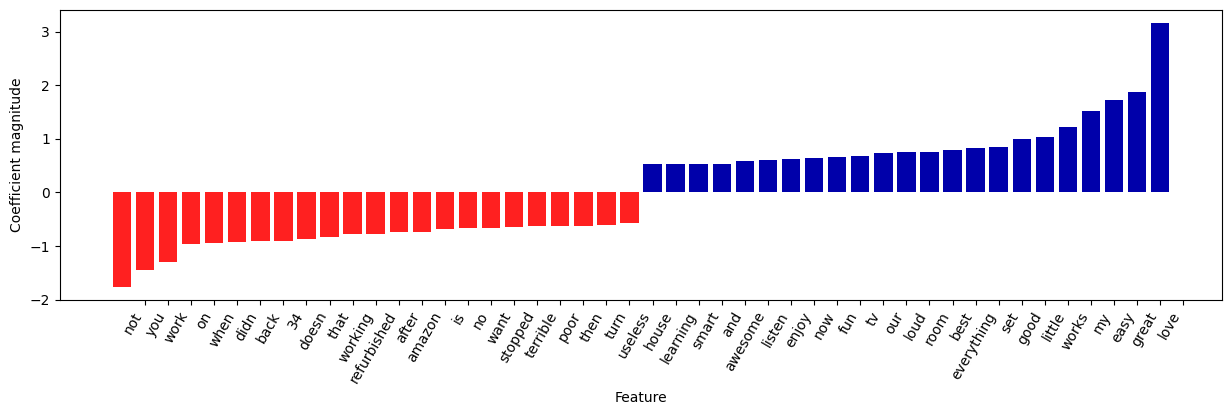

In [ ]:
visualize_coefficients(
    lr_train.coef_,
    features_names,
    n_top_features=23,
)

### 2 Vetorização de Variáveis Categóricas

Considere a Tabela abaixo como um toy dataset para as próximas questões.

Tabela 1.

Imagem

Obs.:

tabela = [
  ["D1", "Sol", "Quente", "Elevada", "Fraco", "Não"],
  ["D2", "Sol", "Quente", "Elevada", "Forte", "Não"],
  ["D3", "Nuvens", "Quente", "Elevada", "Fraco", "Sim"],
  ["D4", "Chuva", "Ameno", "Elevada", "Fraco", "Sim"],
  ["D5", "Chuva", "Fresco", "Normal", "Fraco", "Sim"],
  ["D6", "Chuva", "Fresco", "Normal", "Forte", "Não"],
  ["D7", "Nuvens", "Fresco", "Normal", "Fraco", "Sim"],
  ["D8", "Sol", "Ameno", "Elevada", "Fraco", "Não"],
  ["D9", "Sol", "Fresco", "Normal", "Fraco", "Sim"],
  ["D10", "Chuva", "Ameno", "Normal", "Forte", "Sim"],
  ["D11", "Sol", "Ameno", "Normal", "Forte", "Sim"],
  ["D12", "Nuvens", "Ameno", "Elevada", "Forte", "Sim"],
  ["D13", "Nuvens", "Quente", "Normal", "Fraco", "Sim"],
  ["D14", "Chuva", "Ameno", "Elevada", "Forte", "Não"],
]

**Questão 5**

Vetorize as variáveis categóricas da Tabela 1 utilizando a técnica de One-Hot Encoding.

**Questão 6**

Vetorize as variáveis categóricas da Tabela 1 utilizando a técnica de Dummy Encoding.

**Questão 7**

Vetorize as variáveis categóricas da Tabela 1 utilizando a técnica de Effect Encoding.

**Questão 8**

Compare os resultados obtidos nas questões 5, 6 e 7. Organize a comparação em uma tabela e comente as principais diferenças entre os métodos.

**Questão 9**

Com base nos resultados das questões 5, 6 e 7, explique quais são as vantagens da vetorização de variáveis categóricas.

**Questão 10**

Agora, explique quais seriam as possíveis desvantagens da vetorização de variáveis categóricas, considerando os mesmos resultados.

In [ ]:
tabela = [
  ["D1", "Sol", "Quente", "Elevada", "Fraco", "Não"],
  ["D2", "Sol", "Quente", "Elevada", "Forte", "Não"],
  ["D3", "Nuvens", "Quente", "Elevada", "Fraco", "Sim"],
  ["D4", "Chuva", "Ameno", "Elevada", "Fraco", "Sim"],
  ["D5", "Chuva", "Fresco", "Normal", "Fraco", "Sim"],
  ["D6", "Chuva", "Fresco", "Normal", "Forte", "Não"],
  ["D7", "Nuvens", "Fresco", "Normal", "Fraco", "Sim"],
  ["D8", "Sol", "Ameno", "Elevada", "Fraco", "Não"],
  ["D9", "Sol", "Fresco", "Normal", "Fraco", "Sim"],
  ["D10", "Chuva", "Ameno", "Normal", "Forte", "Sim"],
  ["D11", "Sol", "Ameno", "Normal", "Forte", "Sim"],
  ["D12", "Nuvens", "Ameno", "Elevada", "Forte", "Sim"],
  ["D13", "Nuvens", "Quente", "Normal", "Fraco", "Sim"],
  ["D14", "Chuva", "Ameno", "Elevada", "Forte", "Não"],
]

In [ ]:
df = pd.DataFrame(tabela, columns=["Dia", "Aspecto", "Temp", "Humidade", "Vento", "Jogar_Tenis"])
df

,Dia,Aspecto,Temp,Humidade,Vento,Jogar_Tenis
0,D1,Sol,Quente,Elevada,Fraco,Não
1,D2,Sol,Quente,Elevada,Forte,Não
2,D3,Nuvens,Quente,Elevada,Fraco,Sim
3,D4,Chuva,Ameno,Elevada,Fraco,Sim
4,D5,Chuva,Fresco,Normal,Fraco,Sim
5,D6,Chuva,Fresco,Normal,Forte,Não
6,D7,Nuvens,Fresco,Normal,Fraco,Sim
7,D8,Sol,Ameno,Elevada,Fraco,Não
8,D9,Sol,Fresco,Normal,Fraco,Sim
9,D10,Chuva,Ameno,Normal,Forte,Sim


In [ ]:
cat_features = ['Aspecto', 'Temp', 'Humidade', 'Vento', 'Jogar_Tenis']
cat_features

['Aspecto', 'Temp', 'Humidade', 'Vento', 'Jogar_Tenis']

In [ ]:
# Question 5 vectorizing:

df_one_hot_encoding = pd.get_dummies(df, columns=cat_features, dtype=int)
df_one_hot_encoding.head(5)
print(f"Qtd colunas: {df_one_hot_encoding.shape[1]}")

Qtd colunas: 13


In [ ]:
# Question 6 vectorizing:

df_dummy_encoding = pd.get_dummies(df, columns=cat_features, dtype=int, drop_first=True)
df_dummy_encoding.head(5)
print(f"Qtd colunas: {df_dummy_encoding.shape[1]}")

Qtd colunas: 8


In [ ]:
# Question 7 vectorizing:

df_effect_encoding = patsy.dmatrix('~Aspecto + Temp + Humidade + Vento + Jogar_Tenis', data=df, return_type='dataframe')
df_effect_encoding

df_effect_encoding_all = pd.concat([df[['Dia']], df_effect_encoding], axis=1)
df_effect_encoding_all

,Dia,Intercept,Aspecto[T.Nuvens],Aspecto[T.Sol],Temp[T.Fresco],Temp[T.Quente],Humidade[T.Normal],Vento[T.Fraco],Jogar_Tenis[T.Sim]
0,D1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,D2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,D3,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
3,D4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,D5,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
5,D6,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,D7,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
7,D8,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8,D9,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
9,D10,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
df_one_hot_and_dummy = pd.merge(
    df_one_hot_encoding,
    df_dummy_encoding,
    on='Dia'
)

In [ ]:
df_final = pd.merge(
    df_one_hot_and_dummy,
    df_effect_encoding_all,
    on='Dia'
)

In [ ]:
df_final.head(5)

,Dia,Aspecto_Chuva,Aspecto_Nuvens_x,Aspecto_Sol_x,Temp_Ameno,Temp_Fresco_x,Temp_Quente_x,Humidade_Elevada,Humidade_Normal_x,Vento_Forte,...,Vento_Fraco_y,Jogar_Tenis_Sim_y,Intercept,Aspecto[T.Nuvens],Aspecto[T.Sol],Temp[T.Fresco],Temp[T.Quente],Humidade[T.Normal],Vento[T.Fraco],Jogar_Tenis[T.Sim]
0,D1,0,0,1,0,0,1,1,0,0,...,1,0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,D2,0,0,1,0,0,1,1,0,1,...,0,0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,D3,0,1,0,0,0,1,1,0,0,...,1,1,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
3,D4,1,0,0,1,0,0,1,0,0,...,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,D5,1,0,0,0,1,0,0,1,0,...,1,1,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0


**Question 08 main differences and benefits**

One-Hot Encoding é muito utilizada e mais simples, porém não funciona para muitas colunas.

Dummy evita a possível multicolinearidade da One-Hot Encoding, porém perdemos uma coluna e dificulta a interpretação dos resultados.

E a Effect, traz uma boa interpretação estatística.

**Question 09 explanation**
Como principais vantagens de utilizarmos vetorização de variáveis categóricas, são primeiro a necessidade dos modelos em si que trabalham com números ao invés de texto. E com um bom processo de encoding, os modelos capturam melhor as correalações.

**Question 10 explanation**
A principal desvatagem desse processo de vetorização das variáveis é o aumento de dimensionalidade, pois o número de colunas pode crescer muito. Além de poder gerar multicolinearidade. As matrizes também ficam ainda mais esparsas.

### 3 Outras Técnicas de Transformação de Features

**Questão 11**

Explique o que é e demonstre como pode ser utilizada a técnica de Feature Hashing. Para a demonstração, utilize os dados do toy dataset representado pela Tabela 1.

**Questão 12**

Explique o que é e demonstre como pode ser utilizada a técnica de Bin Counting. Para a demonstração, utilize os dados do toy dataset representado pela Tabela 1.

In [ ]:
df.head()

,Dia,Aspecto,Temp,Humidade,Vento,Jogar_Tenis
0,D1,Sol,Quente,Elevada,Fraco,Não
1,D2,Sol,Quente,Elevada,Forte,Não
2,D3,Nuvens,Quente,Elevada,Fraco,Sim
3,D4,Chuva,Ameno,Elevada,Fraco,Sim
4,D5,Chuva,Fresco,Normal,Fraco,Sim


In [ ]:
df.nunique()

,0
Dia,14
Aspecto,3
Temp,3
Humidade,2
Vento,2
Jogar_Tenis,2
